<a href="https://colab.research.google.com/github/Alissa-Ouspen/data201_alissa/blob/main/week8/OUSPENSKAIA_Project1_Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:
import pandas as pd             # For handling data (DataFrame)
import seaborn as sns           # For visualizations and Planets dataset
import numpy as np              # For numerical operations
import matplotlib.pyplot as plt # For plots
import math

from pandas import plotting

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [147]:
# Planets.csv is in the Seaborn library
# https://github.com/mwaskom/seaborn-data/blob/master/planets.csv
planets = sns.load_dataset("planets")
print(planets.head(5))
print(planets.tail(10))
#type(planets)  # DataFrame

            method  number  orbital_period    mass  distance  year
0  Radial Velocity       1        269.3000  7.1000   77.4000  2006
1  Radial Velocity       1        874.7740  2.2100   56.9500  2008
2  Radial Velocity       1        763.0000  2.6000   19.8400  2011
3  Radial Velocity       1        326.0300 19.4000  110.6200  2007
4  Radial Velocity       1        516.2200 10.5000  119.4700  2009
       method  number  orbital_period  mass  distance  year
1025  Transit       1          3.0679   NaN   60.0000  2012
1026  Transit       1          0.9255   NaN  470.0000  2014
1027  Imaging       1             NaN   NaN   19.2000  2011
1028  Transit       1          3.3521   NaN 3200.0000  2012
1029  Imaging       1             NaN   NaN   10.1000  2012
1030  Transit       1          3.9415   NaN  172.0000  2006
1031  Transit       1          2.6159   NaN  148.0000  2007
1032  Transit       1          3.1915   NaN  174.0000  2007
1033  Transit       1          4.1251   NaN  293.0000  200

In [148]:
# count the number of missing fields by field name

missing = planets.isna().sum()
missing_prop = round(missing / len(planets), 2)
# print(missing_prop)
# type(missing)  # Series: need to convert to DataFrame

In [149]:
missing_df = pd.DataFrame(      #  run only once per session
    {"Missing Count" : missing,
     "Missing Proportion" : missing_prop})

# missing_df = pd.DataFrame()   # alternative
#type(missing_df)  # make sure DataFrame
print(missing_df)

                Missing Count  Missing Proportion
method                      0              0.0000
number                      0              0.0000
orbital_period             43              0.0400
mass                      522              0.5000
distance                  227              0.2200
year                        0              0.0000


In [150]:
# add "Field" column for use as plot labels
missing_df["Field"] = missing_df.index
planet_field_df = pd.DataFrame(      #  run only once per session
    {"Field" : missing_df.index })
planet_field_df["Units"] = (
    "Technique used for discovery", "Num of planets in system", "Earth days",
    "Jupiter Units (M_jup)", "Parsecs (pc) to its star", "Discovery year")
print(planet_field_df)

#  https://deepwiki.com/mwaskom/seaborn-data/8.3-exoplanet-data
#  Distance = from earth or from host star?  in AU or in parsecs?

            Field                         Units
0          method  Technique used for discovery
1          number      Num of planets in system
2  orbital_period                    Earth days
3            mass         Jupiter Units (M_jup)
4        distance      Parsecs (pc) to its star
5            year                Discovery year


------
The planets dataset is a small subset of the data compiled by NASA between
1989 and 2015.  
The NASA dataset includes over 80 columns, while this set  
provided by the Seaborn library only includes six variables.  
It would have been interesting to include more recent years in my analysis  
and include a few other variables, such as the radius of the planet.  
Getting data from a large database is a skill I hope to hone in the next project.

In [151]:
# count the number of unique methods (values in "method" field)

unique_methods = planets["method"].unique()
print(unique_methods)
#type(unique_methods)   # numpy.ndarray

# number of unique methods.  len because array
len(unique_methods)

['Radial Velocity' 'Imaging' 'Eclipse Timing Variations' 'Transit'
 'Astrometry' 'Transit Timing Variations' 'Orbital Brightness Modulation'
 'Microlensing' 'Pulsar Timing' 'Pulsation Timing Variations']


10

In [152]:
print("Descriptive Statistics:\n")
pd.options.display.float_format = '{:.4f}'.format
print(planets.describe())

#help(sns.load_dataset('planets'))

print("\n\n\"planets\" DataFrame summary and data types:\n")
print(planets.info())

Descriptive Statistics:

         number  orbital_period     mass  distance      year
count 1035.0000        992.0000 513.0000  808.0000 1035.0000
mean     1.7855       2002.9176   2.6382  264.0693 2009.0705
std      1.2410      26014.7283   3.8186  733.1165    3.9726
min      1.0000          0.0907   0.0036    1.3500 1989.0000
25%      1.0000          5.4425   0.2290   32.5600 2007.0000
50%      1.0000         39.9795   1.2600   55.2500 2010.0000
75%      2.0000        526.0050   3.0400  178.5000 2012.0000
max      7.0000     730000.0000  25.0000 8500.0000 2014.0000


"planets" DataFrame summary and data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4 

-------------
###Verifying data veracity and unit interpretation

Descriptive statistics show that the minimum orbital period is 0.09 days  
and that the minimum mass is 0.0036.

Investigation confirmed that there are, indeed, planets with ultra-short orbital periods of a few hours.

A mass of 0.0036 seems unreasonably low, but it is reported in units of  
Jupiter Mass $({M_J})$. &nbsp;  0.0036 Jupiter Mass Units is 6.8364 * 10^24 kg, which does seem reasonable. &nbsp; Wikipedia sites a report published by the Royal Astronomical Society, which lists the smallest body considered a planet so far as being ~0.000016 $({M_J})$




Winn, Joshua N.; Sanchis-Ojeda, Roberto; Rappaport, Saul (2018). "Kepler-78 and the Ultra-Short-Period planets". New Astronomy Reviews. 83: 37–48. arXiv:1803.03303. Bibcode:2018NewAR..83...37W. doi:10.1016/j.newar.2019.03.006. S2CID 119190462

https://www.semanticscholar.org/paper/Kepler-78-and-the-Ultra-Short-Period-planets-Winn-Sanchis-Ojeda/a02515776d322a1a428059084385675078aead34

Rappaport, S.; Gary, B. L. (June 2016). "Drifting asteroid fragments around WD 1145+017". Monthly Notices of the Royal Astronomical Society. 458 (4): 3904–3917. arXiv:1602.00740. Bibcode:2016MNRAS.458.3904R. doi:10.1093/mnras/stw612.
https://academic.oup.com/mnras/article/458/4/3904/2613870?login=false

-----------------


#Explanation of Units; References

###Distance:  
"Distance
The distance to the planet-hosting star, in parsecs (pc)."
NASA High Energy Astrophysics Science Archive Research Center (HEASARC)
EXOPLANETS - Extrasolar Planets Encyclopedia:  Parameters
https://heasarc.gsfc.nasa.gov/w3browse/all/exoplanets.html


AU  
The astronomical unit equal to 149,597,870,700 meters.  
Distance between Earth and the Sun = 1 AU.
https://www.bipm.org/documents/20126/41483022/SI-Brochure-9-EN.pdf  
The International System of Units (PDF), V3.01 (9th ed.),  
International Bureau of Weights and Measures, August 2024, p. 145, ISBN 978-92-822-2272-0

${AU} \approx 1.496 * 10^{11}{\text{ m}}$  

https://science.nasa.gov/exoplanets/discoveries-dashboard/  

####Parsec:
"The parsec (symbol: pc) is a unit of length used to measure the large distances to astronomical objects outside the Solar System, approximately equal to 3.26 light-years or 206265 astronomical units (au), i.e. 30.9 trillion kilometres (19.2 trillion miles)."

<br/>

###Mass:  
Jupiter Units
The Jupiter mass, also called Jovian mass, is the unit of mass equal to the total mass of the planet Jupiter.  
Jupiter mass is a common unit of mass in astronomy that is used to indicate the masses of other similarly-sized objects.  
${M_J} \approx 1.898 * 10^{27}{\text{ kg}}$  

https://ssd.jpl.nasa.gov/planets/phys_par.html  
NASA Jet Propulsion Laboratory, California Institute of Technology  
Solar System Dynamics Group page "Planetary Physical Parameters".  
Updated December 12, 2019.  Viewed March 29, 2026.  
Planet_Mass

From "EXOPLANETS - Extrasolar Planets Encyclopedia"  
Parameters:   
"The mass (or minimum mass) of the extrasolar planet, in Jupiter masses. For planets detected by radial velocity and timing, only the product M.sini, where i is the orbit inclination, is known in general. For transiting planets, i, hence M, is known from the fitting of the transit light curve. For planets detected by astrometry, i is directly inferred from the parent star orbit. For planets detected by radial velocity in multiplanet systems, it can sometimes be inferred from the dynamical analysis of the planet-planet interaction, and in a few years it will be inferred from direct imaging of some planets. Thus, when the inclination is known, rather than the value of M.sini i the true mass value M is given."
- NASA High Energy Astrophysics Science Archive Research Center (HEASARC)

https://heasarc.gsfc.nasa.gov/w3browse/all/exoplanets.html  
 last updated on 31 March 2026.


<br/>

###Example of usage:  
"TOI-5916 b is a gas giant exoplanet that orbits a M-type star.  
Its mass is 0.713 Jupiters, it takes 2.4 days to complete one orbit of its star, and is 0.0262 AU from its star."  
https://science.nasa.gov/exoplanet-catalog/toi-5916-b/
NASA "Eyes on Exoplanets" dashboard.  

<br/>


####Astronomical Units vs Lightyears:  
https://science.nasa.gov/solar-system/cosmic-distances/



In [153]:
# Data transformations

planets_transf = pd.DataFrame(  # must be numpy operation not math for DF
    {"sqrt_mass" : np.sqrt(planets["mass"]),
     "inv_mass" : 1/ planets["mass"],
     "ln_distance" : np.log(planets["distance"]) ,
     "log2_distance" : np.log2(planets["distance"]),
     "log_orbit": np.log(planets["orbital_period"])}
)

sqrt_mass = planets_transf["sqrt_mass"]
inv_mass = planets_transf["inv_mass"]
ln_distance = planets_transf["ln_distance"]
log2_distance = planets_transf["log2_distance"]
log_orbit = planets_transf["log_orbit"]

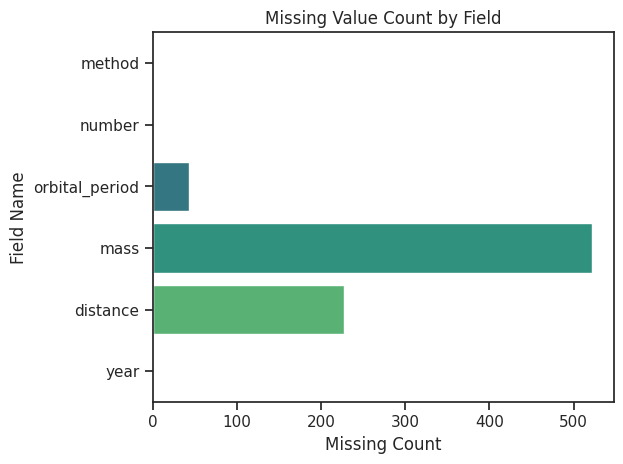

In [154]:
# Plot Missing values

sns.barplot(    # Horizontally-oriented bars
    data = missing_df, y = "Field", x = "Missing Count",
                hue = "Field", legend = False, palette = "viridis")
plt.title("Missing Value Count by Field")
plt.xlabel("Missing Count")
plt.ylabel("Field Name")
plt.tight_layout()
plt.show()


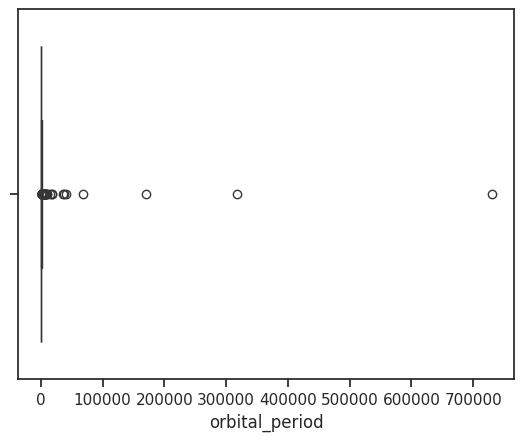

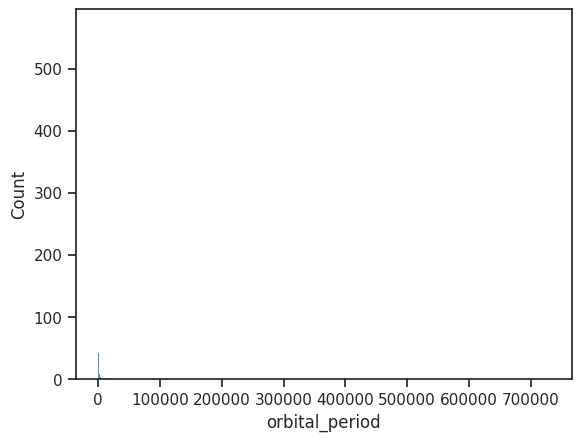

In [155]:
# Histogram of orbital periods

sns.boxplot(data = planets, x = "orbital_period")
plt.show()
sns.histplot(data = planets, x = "orbital_period")
plt.show()

Orbital periods are heavily right-skewed by extreme outliers.
-------------

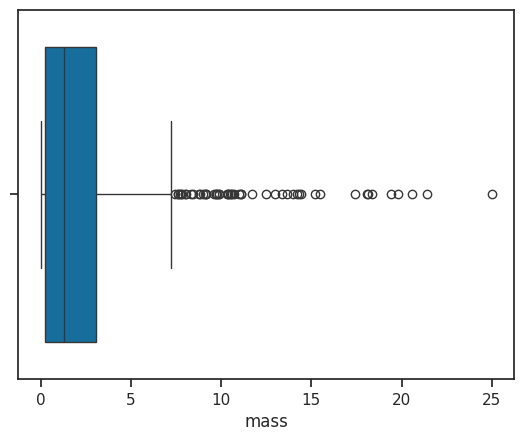

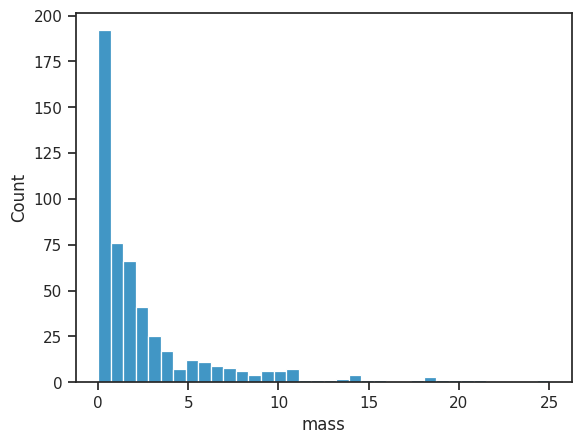

In [156]:
# Histogram of masses

sns.boxplot(data = planets, x = "mass")
plt.show()
sns.histplot(data = planets, x = "mass")
plt.show()

Masses are heavily skewed right by outliers
-----------------

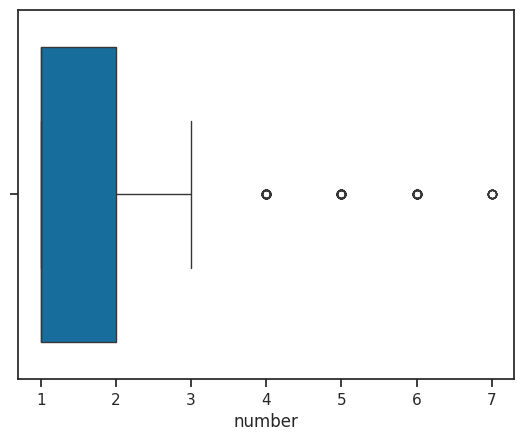

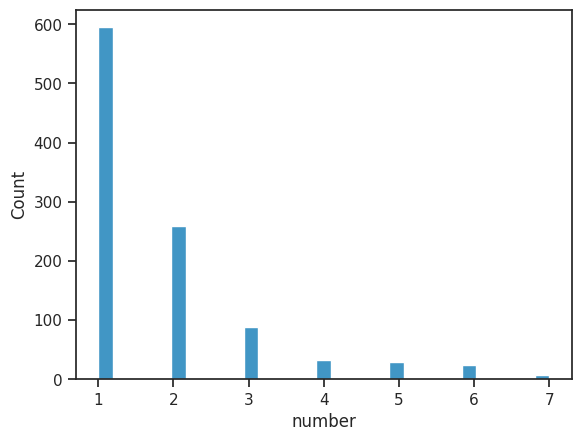

In [157]:
# Histogram of number of planets found in the star's system

sns.boxplot(data = planets, x = "number")
plt.show()
sns.histplot(data = planets, x = "number")
plt.show()

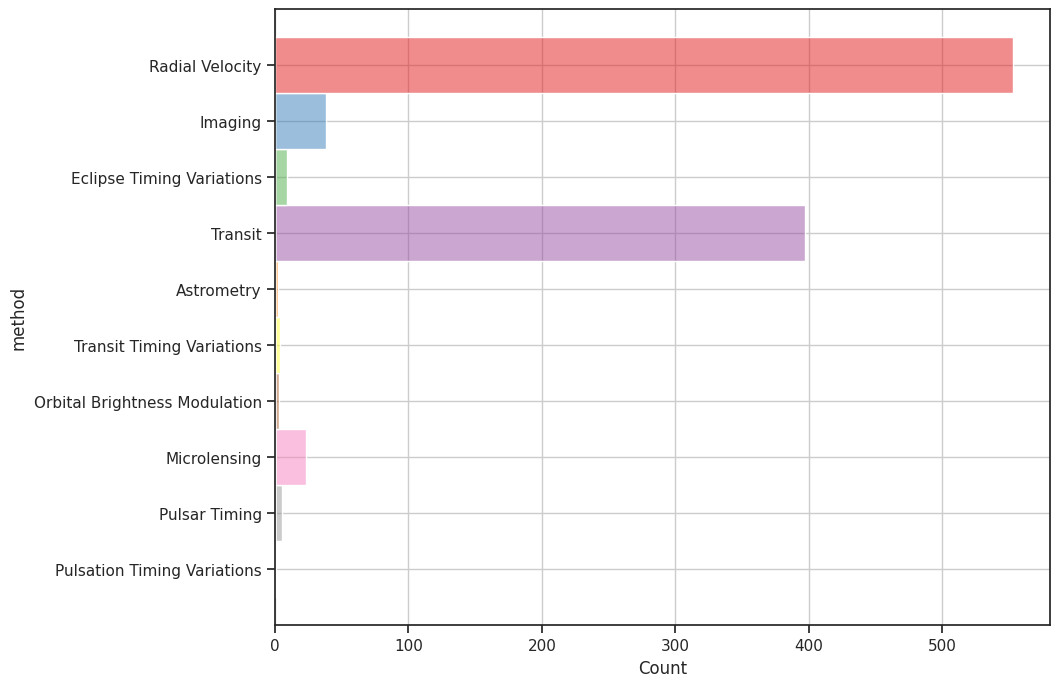

In [158]:
#  Histogram of methods

plt.figure(figsize = (10, 8))
sns.histplot(
    data = planets, y = "method", hue = "method",
    palette = "Set1", legend = False)
plt.grid()
plt.show()

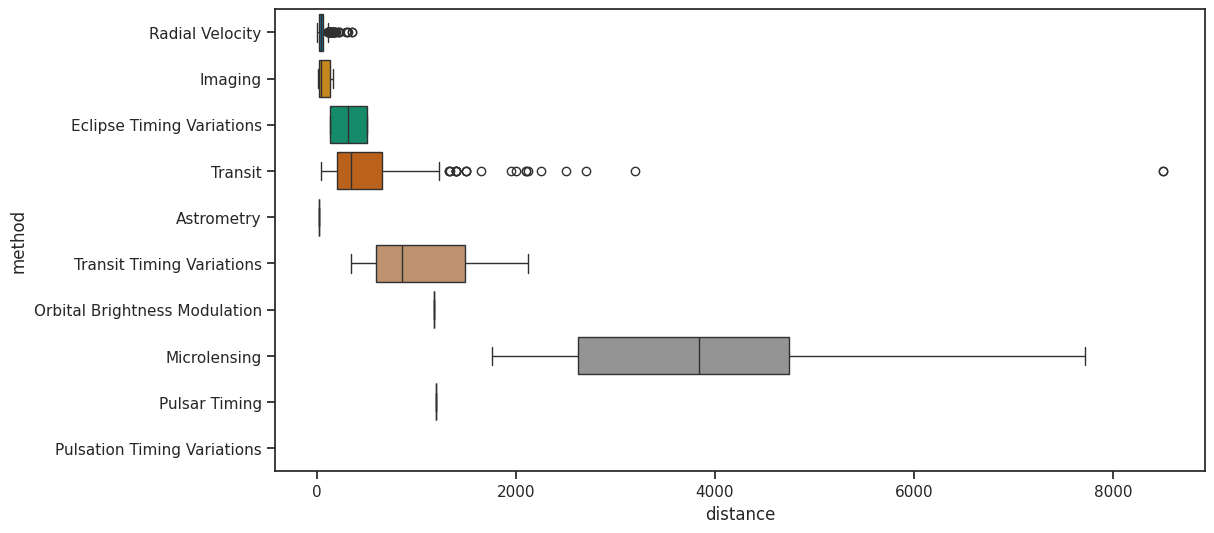

In [159]:
# Boxplots of distance by method

plt.figure(figsize = (12, 6))
sns.boxplot(data = planets, y = "method", x = "distance", hue = "method")
plt.show()

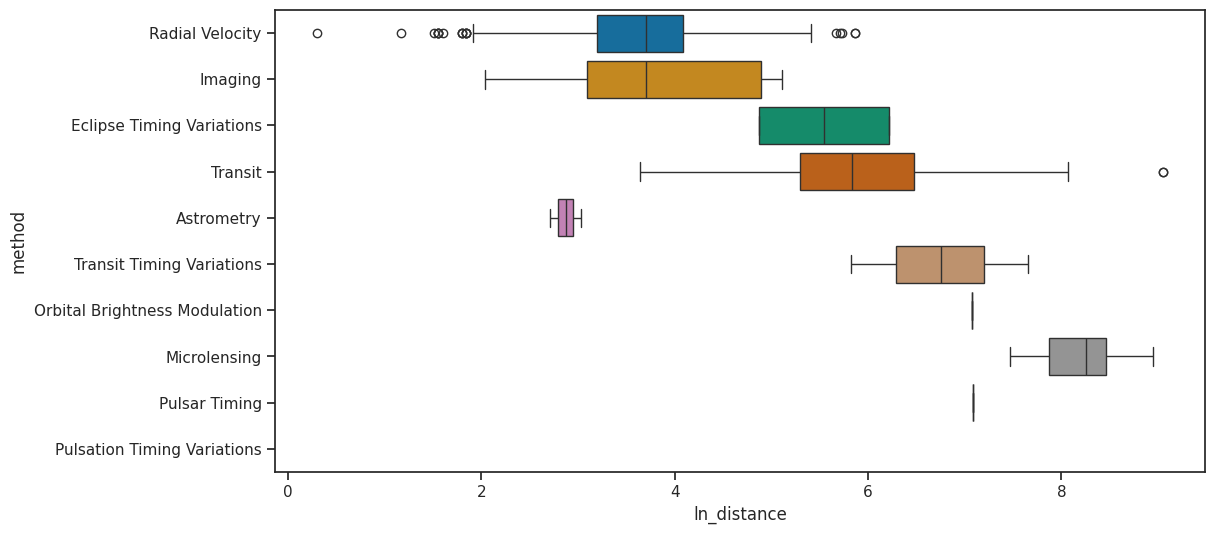

In [160]:
# transformed distance vs method
plt.figure(figsize = (12, 6))
sns.boxplot(data = planets, y = "method", x = ln_distance, hue = "method")
plt.show()

In [161]:
# was pulsation timing method used?

planets.loc[planets["method"] == "Pulsation Timing Variations"]

,method,number,orbital_period,mass,distance,year
958,Pulsation Timing Variations,1,1170.0000,NaN,NaN,2007


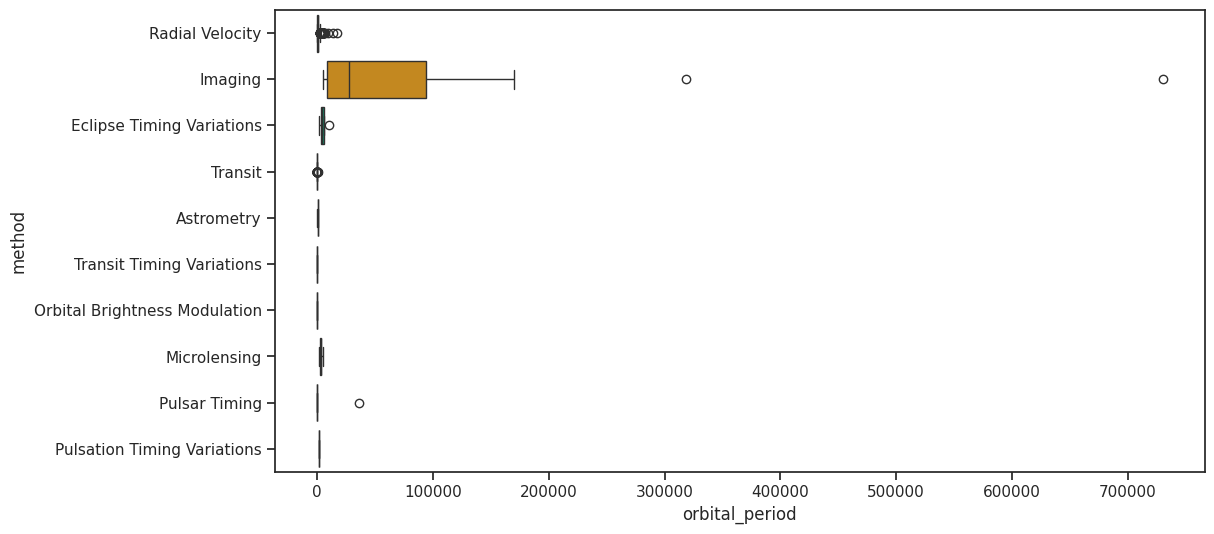

In [162]:
plt.figure(figsize = (12, 6))
sns.boxplot(data = planets, y = "method", x = "orbital_period", hue = "method")
plt.show()

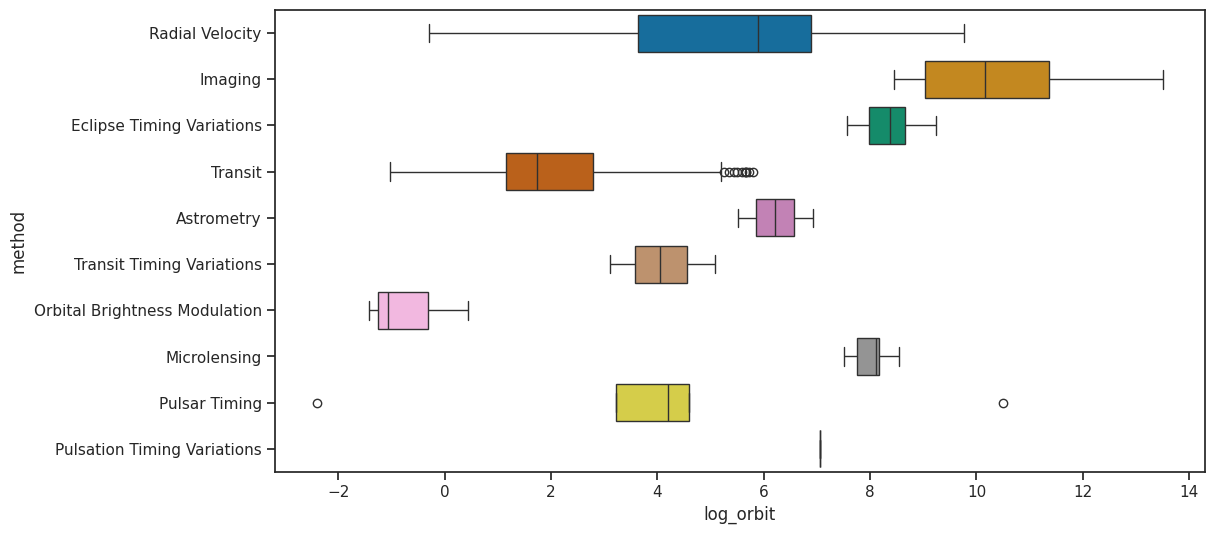

In [163]:
# transformed orbit vs method
plt.figure(figsize = (12, 6))
sns.boxplot(data = planets, y = "method", x = log_orbit, hue = "method")
plt.show()

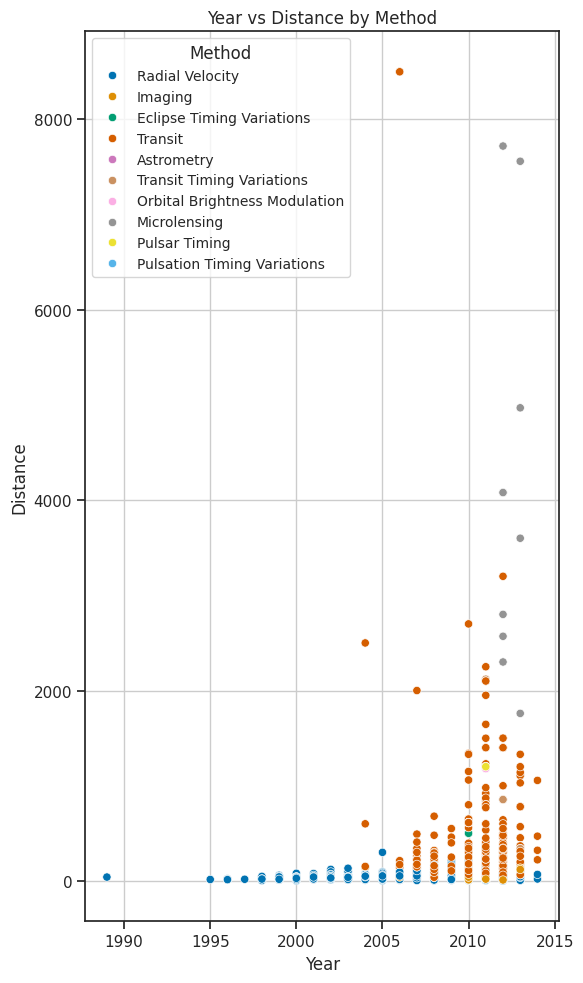

In [164]:
# scatterplot distance vs year

sns.set_theme(style = "ticks", palette = "colorblind")

plt.figure(figsize = (6, 10))
sns.scatterplot(
    data = planets, x = "year", y = "distance", hue = "method")
plt.xlabel("Year")
plt.ylabel("Distance")
plt.title("Year vs Distance by Method")
plt.gca().legend_.set_title("Method")
plt.grid()
plt.legend(fontsize = "small", title = "Method")
plt.tight_layout()
plt.show()

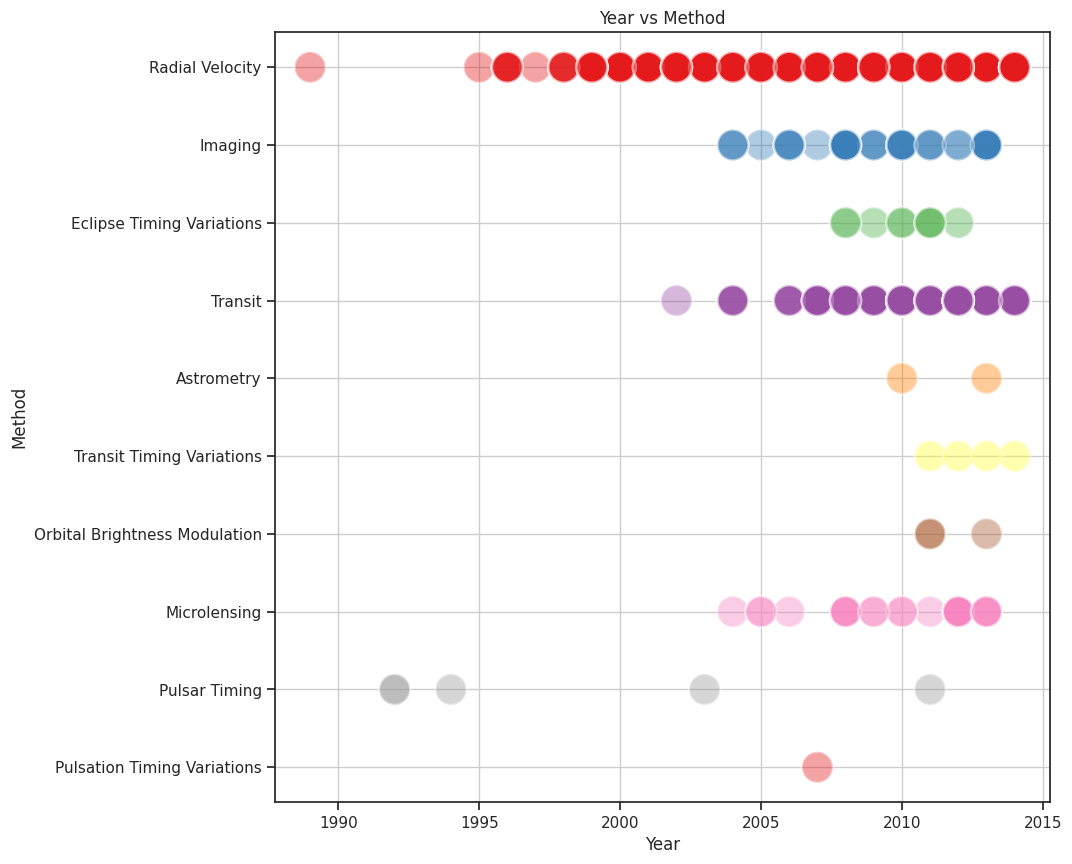

In [165]:
# scatterplot year vs method

plt.figure(figsize = (10, 10))
sns.scatterplot(
    data = planets, x = "year", y = "method", palette = "Set1",
    s = 500, hue = "method", alpha = 0.4, legend = False)
plt.xlabel("Year")
plt.ylabel("Method")
plt.title("Year vs Method")
plt.grid()
plt.show()

Ideally, I'd like to create a category for the frequency of events in each intersection (pair) and have the marker sizes represent points where there is more overlapping data.  For now, color saturation approximates this information.
-------------
---------------

In [166]:
# ln(distance) ~ method

reg_method_distance = smf.ols(
    "ln_distance ~ C(method)", data = planets).fit()

reg_method_distance.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ln_distance   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     175.3
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          4.24e-170
Time:                        03:55:49   Log-Likelihood:                -1012.2
No. Observations:                 808   AIC:                             2042.
Df Residuals:                     799   BIC:                             2085.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      2.8701      0.602      4.766      0.000       1.688       4.052
C(method)[T.Eclipse Timing Variations]         2.6737      0.738      3.625      0.000       1.226       4.121
C(method)[T.Imaging]                           0.9700      0.621      1.563      0.119      -0.248       2.188
C(method)[T.Microlensing]                      5.3511      0.660      8.112      0.000       4.056       6.646
C(method)[T.Orbital Brightness Modulation]     4.2032      0.852      4.935      0.000       2.531       5.875
C(method)[T.Pulsar Timing]                     4.2200      1.043      4.046      0.000       2.173       6.267
C(method)[T.Pulsation Timing Variations]   -1.275e-16   3.49e-16     -0.365      0.715   -8.13e-16    5.58e-16
C(method)[T.Radial Velocity]                   0.7664      0.603      1.270      0.204      -0.418       1.951
C(method)[T.Transit]                           3.0317      0.605      5.012      0.000       1.844       4.219
C(method)[T.Transit Timing Variations]         3.8752      0.777      4.985      0.000       2.349       5.401
==============================================================================
Omnibus:                        7.712   Durbin-Watson:                   1.199
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                9.828
Skew:                          -0.103   Prob(JB):                      0.00734
Kurtosis:                       3.500   Cond. No.                     1.87e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.56e-32. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

Here, I wanted to find out whether I could use the discovery method to predict  
distance from a planet's star.  In the boxplots, it seemed like this would be  
possible, especially if two or three of the methods were excluded.  
As predicted, running the regression produced significant correlation  coefficients  
for some of the methods, although the R-squared value is low,  
showing that only 64% of the variance in distance can be explained by the method.  
What confuses me is that removing those methods that did not have a  significant  
relationship with distance made the significance of the relationship with the other  
methods decrease.  Apparently, I do not understand how this model works and need  
to conduct further research on linear regression modeling.  

In [167]:
# Remove methods that don't correlate with distance
drop_rows = planets[(
    (planets["method"] == "Pulsation Timing Variations") | (
        planets["method"] == "Radial Velocity") | (
            planets["method"] == "Imaging"))].index

methods_culled = planets.drop(drop_rows)
methods_culled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 32 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          443 non-null    object 
 1   number          443 non-null    int64  
 2   orbital_period  426 non-null    float64
 3   mass            3 non-null      float64
 4   distance        246 non-null    float64
 5   year            443 non-null    int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 24.2+ KB


In [168]:
# method vs distance
ln_culled_distance = pd.DataFrame({"ln_distance" : np.log(methods_culled["distance"])
})

reg_method_distance = smf.ols(
    "distance ~ C(method)", data = methods_culled).fit()

reg_method_distance.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               distance   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     21.61
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           3.02e-20
Time:                        03:55:49   Log-Likelihood:                -2038.4
No. Observations:                 246   AIC:                             4091.
Df Residuals:                     239   BIC:                             4115.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     17.8750    688.926      0.026      0.979   -1339.267    1375.017
C(method)[T.Eclipse Timing Variations]       297.4850    843.758      0.353      0.725   -1364.668    1959.638
C(method)[T.Microlensing]                   4126.1250    754.681      5.467      0.000    2639.450    5612.800
C(method)[T.Orbital Brightness Modulation]  1162.1250    974.288      1.193      0.234    -757.164    3081.414
C(method)[T.Pulsar Timing]                  1182.1250   1193.255      0.991      0.323   -1168.514    3532.764
C(method)[T.Transit]                         581.4231    691.995      0.840      0.402    -781.764    1944.611
C(method)[T.Transit Timing Variations]      1086.4583    889.400      1.222      0.223    -665.605    2838.522
==============================================================================
Omnibus:                      291.223   Durbin-Watson:                   1.199
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14713.174
Skew:                           5.055   Prob(JB):                         0.00
Kurtosis:                      39.513   Cond. No.                         42.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-squared got worse
-----------
---------


In [169]:
# Orbit ~ sqrt(mass) + distance

reg_orbit_mass_distance = smf.ols(
    "orbital_period ~ sqrt_mass + distance", data = planets).fit()

reg_orbit_mass_distance.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         orbital_period   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     24.54
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           6.90e-11
Time:                        03:55:49   Log-Likelihood:                -4314.2
No. Observations:                 498   AIC:                             8634.
Df Residuals:                     495   BIC:                             8647.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    473.5635    112.039      4.227      0.000     253.432     693.695
sqrt_mass    484.0079     69.566      6.958      0.000     347.327     620.689
distance      -4.6979      1.447     -3.247      0.001      -7.541      -1.855
==============================================================================
Omnibus:                      565.290   Durbin-Watson:                   2.042
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            44428.233
Skew:                           5.203   Prob(JB):                         0.00
Kurtosis:                      48.087   Cond. No.                         133.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

----------

Is there a significant relationship between planet mass, distance to its star, and the orbital period?

Simple linear regression with this data indicates a significant (alpha < .01)  
positive relationship between mass and orbital period and a significant (alpha < .05)negative relationship between distance and orbital period.
However, background research suggests the relationship should be negative.  
If planet radii and their suns' masses were held constant, the orbital period should decrease with mass:  

Orbital Period (T):
T = 2 * π * √(a^3 / G * (m1 + m2))

As the mass of the planet increases, the orbital period decreases, assuming a constant semi-major axis.
https://blog.truegeometry.com/tutorials/education/f0710032c335bcc8fe2283fee0017ba4/JSON_TO_ARTCL_Impact_of_Planet_Mass_on_Orbital_Dynamics_in_context_of_planet_mas.html

The regression analysis does not show a strong relationship, though.  Only 9% if the variance in orbital period can be described by planetary mass and distance to its star.

------------------

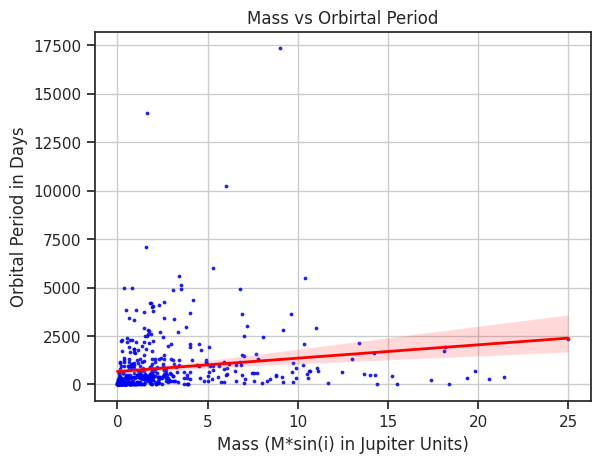

In [170]:
# Mass vs Orbit
sns.regplot(
    data = planets,
    x = "mass",
    y = "orbital_period",
    scatter = True,
    color = "blue",
    scatter_kws = {"s" : 3},
    line_kws = {"linewidth": 2, "color" : "red"}
)
plt.xlabel("Mass (M*sin(i) in Jupiter Units)")
plt.ylabel("Orbital Period in Days")
plt.title("Mass vs Orbirtal Period")
plt.grid()
plt.show()

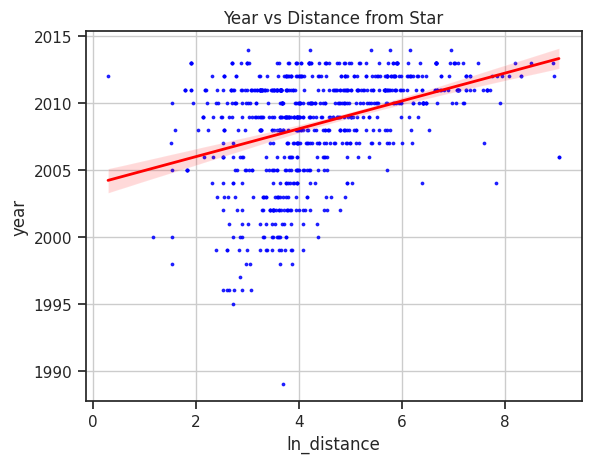

In [171]:
#  Regression & Plot for Year vs Distance
sns.regplot(
    data = planets,
    y = "year",
    x = ln_distance,
    scatter = True,
    color = "blue",
    scatter_kws = {"s" : 3},
    line_kws = {"linewidth": 2, "color" : "red"}
)

plt.title("Year vs Distance from Star")
plt.grid()
plt.show()

In [175]:
# year vs distance

reg_year_distance = smf.ols(
    "year ~  distance", data = planets).fit()

reg_year_distance.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   year   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     26.66
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           3.07e-07
Time:                        03:55:50   Log-Likelihood:                -2241.4
No. Observations:                 808   AIC:                             4487.
Df Residuals:                     806   BIC:                             4496.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2008.2001      0.145   1.38e+04      0.000    2007.915    2008.485
distance       0.0010      0.000      5.163      0.000       0.001       0.001
==============================================================================
Omnibus:                      143.194   Durbin-Watson:                   1.395
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              225.009
Skew:                          -1.174   Prob(JB):                     1.38e-49
Kurtosis:                       4.083   Cond. No.                         828.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [185]:
# year vs ln(distance)

reg_year_distance = smf.ols(
    "year ~  ln_distance", data = planets).fit()

reg_year_distance.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   year   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     128.8
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           8.39e-28
Time:                        04:22:21   Log-Likelihood:                -2194.6
No. Observations:                 808   AIC:                             4393.
Df Residuals:                     806   BIC:                             4403.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2003.9156      0.420   4769.779      0.000    2003.091    2004.740
ln_distance     1.0407      0.092     11.350      0.000       0.861       1.221
==============================================================================
Omnibus:                       97.597   Durbin-Watson:                   1.513
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              134.809
Skew:                          -0.898   Prob(JB):                     5.33e-30
Kurtosis:                       3.883   Cond. No.                         15.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

It is much more difficult to find planets, the farther  
out from their star they are located.  
I was surprised to find that the correlation between year and distance  
to a planet's star is so weak.  
Although the correlation coefficient is shown to be significant at the  
alpha = 0.01 level, the R-squared value is low:  only 14% of the variance  
in the year is explained by the distance.  
The reason this surprises me is I would have thought that with time,  
technological capability improves, and the increased amount of data  
available for analysis would make it more likely that planets farther  
from their stars can be located.   
-------------
-----------



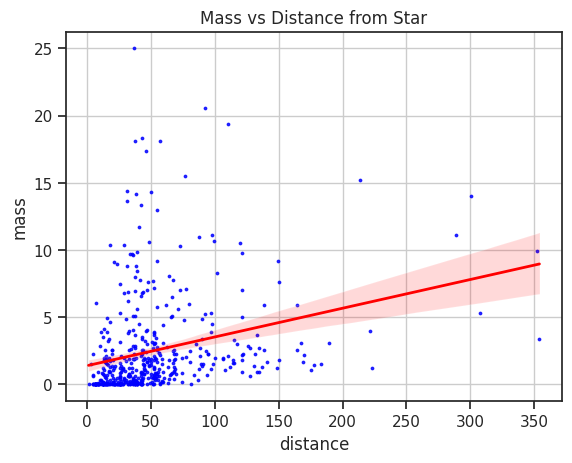

In [172]:
#  Regression & Plot for Mass vs Distance
sns.regplot(
    data = planets,
    y = "mass",
    x = "distance",
    scatter = True,
    color = "blue",
    scatter_kws = {"s" : 3},
    line_kws = {"linewidth": 2, "color" : "red"}
)

plt.title("Mass vs Distance from Star")
plt.grid()
plt.show()

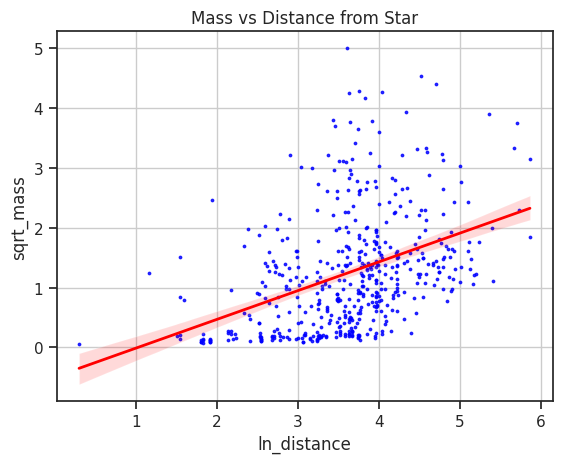

In [173]:
#  Regression & Plot for sqrt(Mass) vs ln(Distance)
sns.regplot(
    data = planets,
    y = sqrt_mass,
    x = ln_distance,
    scatter = True,
    color = "blue",
    scatter_kws = {"s" : 3},
    line_kws = {"linewidth": 2, "color" : "red"}
)

plt.title("Mass vs Distance from Star")
plt.grid()
plt.show()

In [174]:
#  sqrt(Mass) vs ln(Distance)

reg_mass_distance = smf.ols(
    "sqrt_mass ~  ln_distance", data = planets).fit()

reg_mass_distance.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              sqrt_mass   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     98.12
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           3.15e-21
Time:                        03:55:50   Log-Likelihood:                -645.59
No. Observations:                 498   AIC:                             1295.
Df Residuals:                     496   BIC:                             1304.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.4928      0.181     -2.727      0.007      -0.848      -0.138
ln_distance     0.4801      0.048      9.906      0.000       0.385       0.575
==============================================================================
Omnibus:                       97.781   Durbin-Watson:                   1.702
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              158.872
Skew:                           1.215   Prob(JB):                     3.17e-35
Kurtosis:                       4.323   Cond. No.                         18.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [176]:
# Log orbit vs sqrt mass

reg_orbit_mass = smf.ols(
    "log_orbit ~  sqrt_mass", data = planets).fit()

reg_orbit_mass.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_orbit   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     134.4
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           9.46e-28
Time:                        03:55:51   Log-Likelihood:                -1053.7
No. Observations:                 513   AIC:                             2111.
Df Residuals:                     511   BIC:                             2120.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0519      0.137     29.681      0.000       3.784       4.320
sqrt_mass      0.9744      0.084     11.593      0.000       0.809       1.139
==============================================================================
Omnibus:                       21.085   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.643
Skew:                          -0.509   Prob(JB):                     1.21e-05
Kurtosis:                       3.149   Cond. No.                         3.37
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

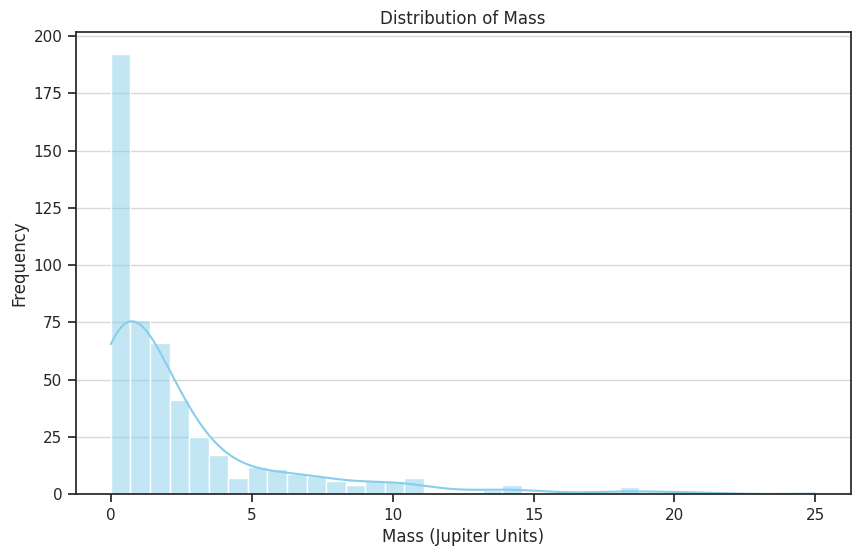

In [177]:
plt.figure(figsize = (10, 6))
sns.histplot(data = planets, x = "mass", kde = True, color = 'skyblue')
plt.title("Distribution of Mass")
plt.xlabel("Mass (Jupiter Units)")
plt.ylabel("Frequency")
plt.grid(axis = 'y', alpha = 0.75)
plt.show()

In [178]:
pearson_corr = sqrt_mass.corr(log_orbit, method = 'pearson')
print(f"Pearson correlation between sqrt_mass and log_orbit: {pearson_corr:.4f}")

Pearson correlation between sqrt_mass and log_orbit: 0.4563


In [179]:
spearman_corr = sqrt_mass.corr(log_orbit, method = 'spearman')
print(f"Spearman correlation between sqrt_mass and log_orbit: {spearman_corr:.4f}")

Spearman correlation between sqrt_mass and log_orbit: 0.5422


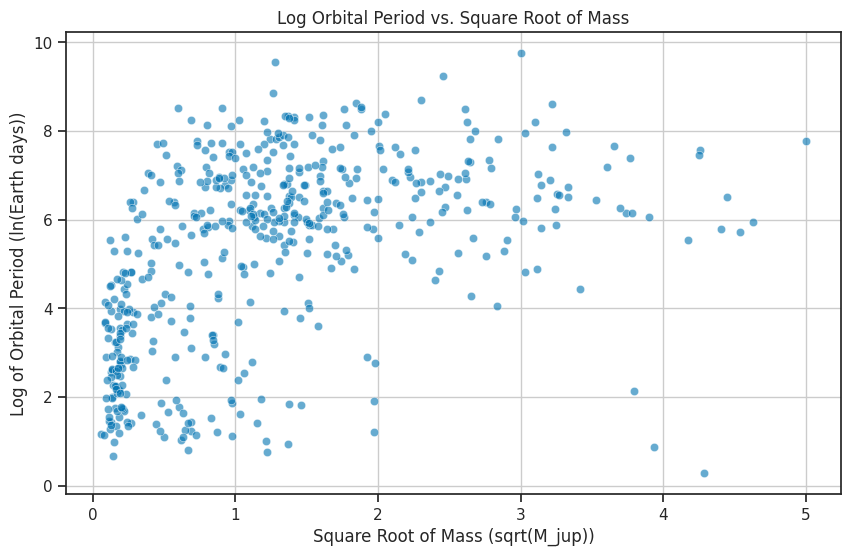

In [180]:
plt.figure(figsize = (10, 6))
sns.scatterplot(
    x = sqrt_mass,
    y = log_orbit,
    data = planets_transf,
    alpha = 0.6  # Use the DataFrame where these transformed variables are stored
)
plt.xlabel("Square Root of Mass (sqrt(M_jup))")
plt.ylabel("Log of Orbital Period (ln(Earth days))")
plt.title("Log Orbital Period vs. Square Root of Mass")
plt.grid(True)
plt.show()

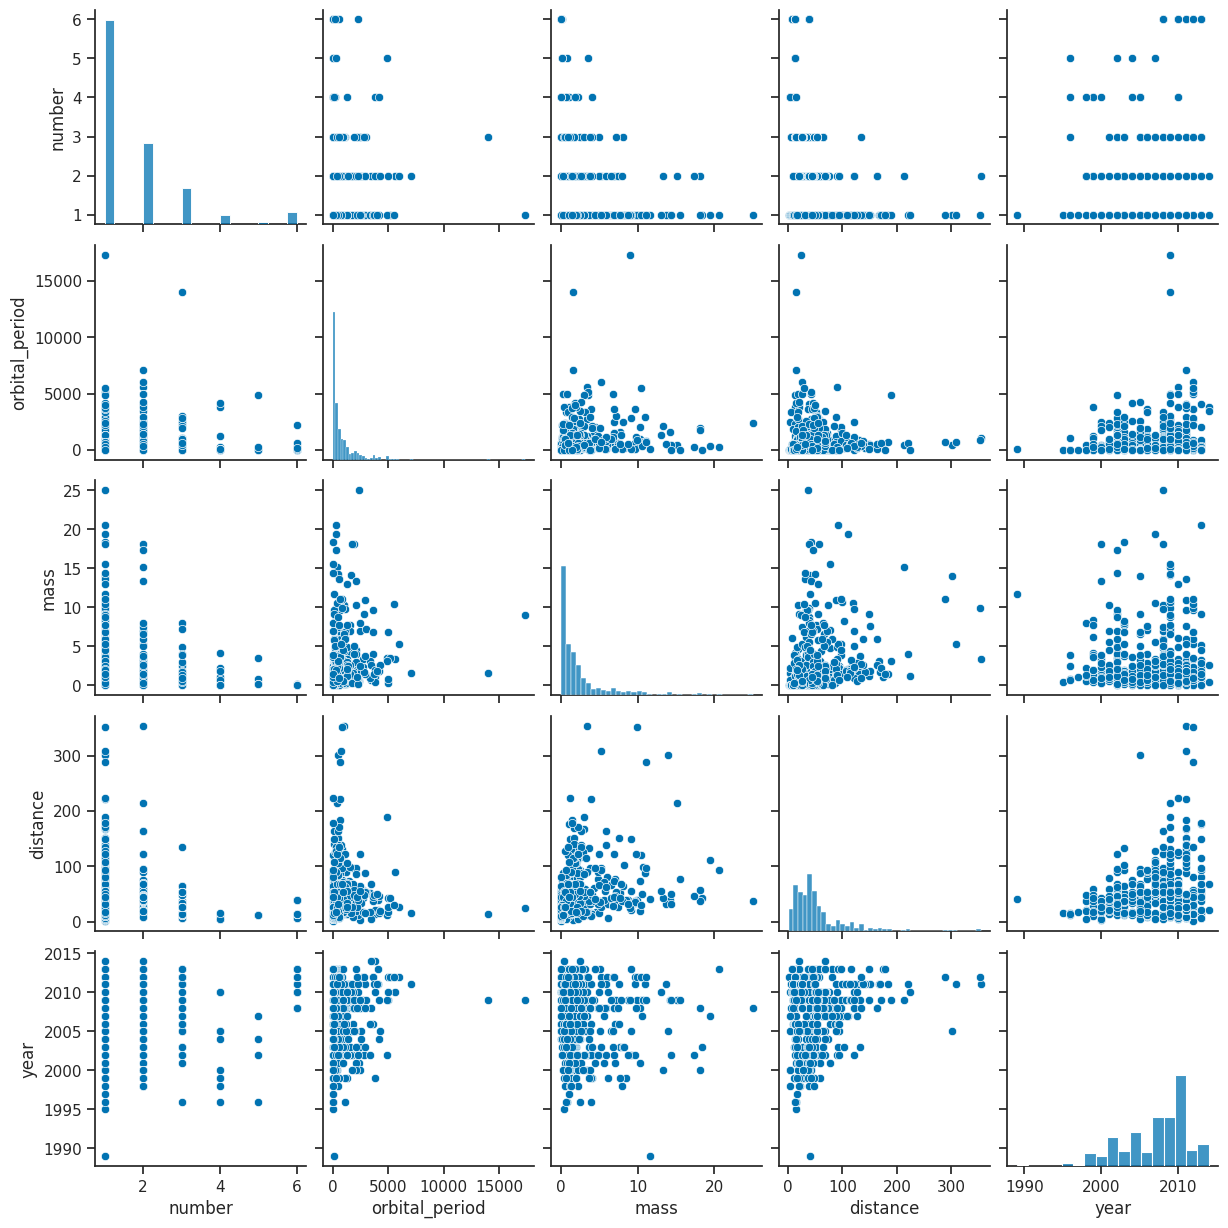

In [184]:
# things looked weird without dropna()
sns.pairplot(planets[["number", "orbital_period", "mass", "distance", "year"]].dropna())
plt.show()

Simulate a nonparametric inference of the median for one quantitative variable
Use a random sample (~10% of the data)

Nonparametric Median Estimate for Orbital Period (from 10% sample): 75.74 days
95% Confidence Interval: (17.85, 194.30) days


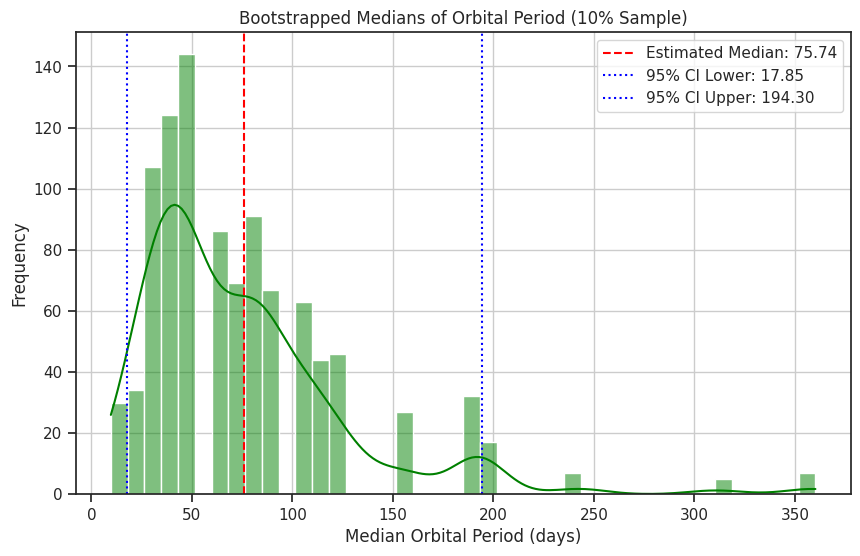

In [182]:
# drop NaN
orbital_period_data = planets["orbital_period"].dropna()

# take random sample ~10%
sample_size = int(len(orbital_period_data) * 0.1)
random_sample = orbital_period_data.sample(n = sample_size, random_state = 42)

# bootstrapping for median inference 1000 times
num_bootstraps = 1000
bootstrapped_medians = []

for _ in range(num_bootstraps):           # with replacement
    bootstrap_sample = random_sample.sample(n = sample_size, replace = True)
    bootstrapped_medians.append(bootstrap_sample.median())

# mean of bootstrapped medians
median_estimate = np.mean(bootstrapped_medians)

# 95% confidence interval
lower_bound = np.percentile(bootstrapped_medians, 2.5)
upper_bound = np.percentile(bootstrapped_medians, 97.5)

print(
    f"Nonparametric Median Estimate for Orbital Period (from 10% sample): {median_estimate:.2f} days")
print(
    f"95% Confidence Interval: ({lower_bound:.2f}, {upper_bound:.2f}) days")

# plot distribution of bootstrapped medians
plt.figure(figsize = (10, 6))
sns.histplot(bootstrapped_medians, kde = True, color = "green")
plt.axvline(x = median_estimate, color = 'red', linestyle = '--', label = f'Estimated Median: {median_estimate:.2f}')
plt.axvline(x = lower_bound, color = 'blue', linestyle = ':', label = f'95% CI Lower: {lower_bound:.2f}')
plt.axvline(x = upper_bound, color = 'blue', linestyle = ':', label = f'95% CI Upper: {upper_bound:.2f}')
plt.title("Bootstrapped Medians of Orbital Period (10% Sample)")
plt.xlabel("Median Orbital Period (days)")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

--------------------------------------
Ideas for future research:
As mentioned earlier, including the radii of the planets may have  
made the  dataset more interesting and allowed for meaningful analyses.  
Perhaps, much of these fields were missing for the years in question.  
Additionally, I realized too late that it may have proved enlightening  
to look for patterns in the missing data itself:  &nbsp; could there have been  
some correlations between the methods used to detect the planets and the  
type of data that were less available?  
Perhaps, certain methods were less capable of detecting the mass, distance,  
or orbital period of a planet.
------------------

##Use of AI and reference material disclosure statement:  

Google Gemini was used to troubleshoot code, after several attempts to fix code failed.  
Independent attempts to fix code included making changes in response to error messages,  
reading documentation, and searching for suggestions online.  
Gemini was also used to get suggestions for customized formatting,  
after independent attempts were made. &nbsp;   
Many suggestions were rejected, and a lot were further customized independently.  
Each suggestion was evaluated against original code, to gain understanding about   
how and why particular statements do or do not work.  
AI was ***not*** used to avoid frustration or to significantly curtail the amount of time spent  
on the assignment.

Overall, AI was used to enrich practical experience and deepen understanding  
of the libraries and their attributes and how they interact with one another.    
It allowed more efficient exploration of how general code provided in course  
materials can be customized to fit particular situations and to dig deeper  
into questions about the data.    

Duck.ai was used to expedite Web searches, after conventional search attempts  
proved unreasonably time-consuming or unfruitful.  These included help with  
locating a list of datasets with 1,000 or more rows and explanations of the  
units used for mass and distance in the dataset.  
The most notably helpful search performed by Duck.ai was locating a reliable  
and authoritative source resolving the question of units used for distance:  
Seaborn documentation did not explain which units were used  
(lightyears/ Astronomical Units/ parsecs) and what they measured  
(distance from Earth or distance from the planet's hosting star).  
Various reference materials provided contradictory information.  
There remains some confusion about the relationship of the AU to the parsec,  
but the detailed explanation is outside the scope of the analysis of the  
dataset at this time.  

General searches on the Web were conducted conventionally to find examples of  
visualizations, when those attempted proved visually or structurally unsatisfactory.